In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

os.makedirs('../outputs/visualizations/static', exist_ok=True)
os.makedirs('../outputs/visualizations/interactive', exist_ok=True)

STATIC_DIR = '../outputs/visualizations/static'
INTERACTIVE_DIR = '../outputs/visualizations/interactive'

df_raw = pd.read_csv('../data/processed/cleaned/cleaned_data.csv')
df = df_raw.rename(columns={
    'data.make': 'make',
    'data.model': 'model',
    'data.year': 'modelYear',
    'data.document_type': 'component',
    'data.description': 'consequence_summary',
})
df = df[df['make'].notna() & ~df['make'].isin(['Unknown', 'UNKNOWN'])]
df['component'] = df['component'].fillna('Unknown')
df['consequence_summary'] = df['consequence_summary'].fillna('')
print(f'Loaded {len(df)} records')
df.head()

Loaded 21 records


,source,fetched_at,version,_collection,make,model,modelYear,data.recalls,data.file_name,component,...,data.exif.date_taken,data.exif.exposure_time,data.exif.aperture,data.exif.iso,data.exif.focal_length,data.exif.orientation,data.exif.gps,data.exif.extracted_at,data.processed_at,release_year
0,test,2026-03-23 22:57:44.926,1.0,raw_recalls,Audi,A4,2020.0,[],NaN,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026
1,nhtsa_api,2026-03-23 23:02:08.429,1.0,raw_recalls,Skoda,OCTAVIA,2020.0,[],NaN,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026
5,dynamic_scraping,2026-04-02 16:24:55.801,1.0,raw_recalls,Audi,A4,2020.0,[{'Manufacturer': 'Volkswagen Group of America...,NaN,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026
11,nhtsa_api,2026-01-01,1.0,raw_recalls,Audi,A4,2020.0,NaN,NaN,BRAKES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020
12,nhtsa_api,2026-01-01,1.0,raw_recalls,Audi,A4,2019.0,NaN,NaN,ENGINE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019


## Static Charts

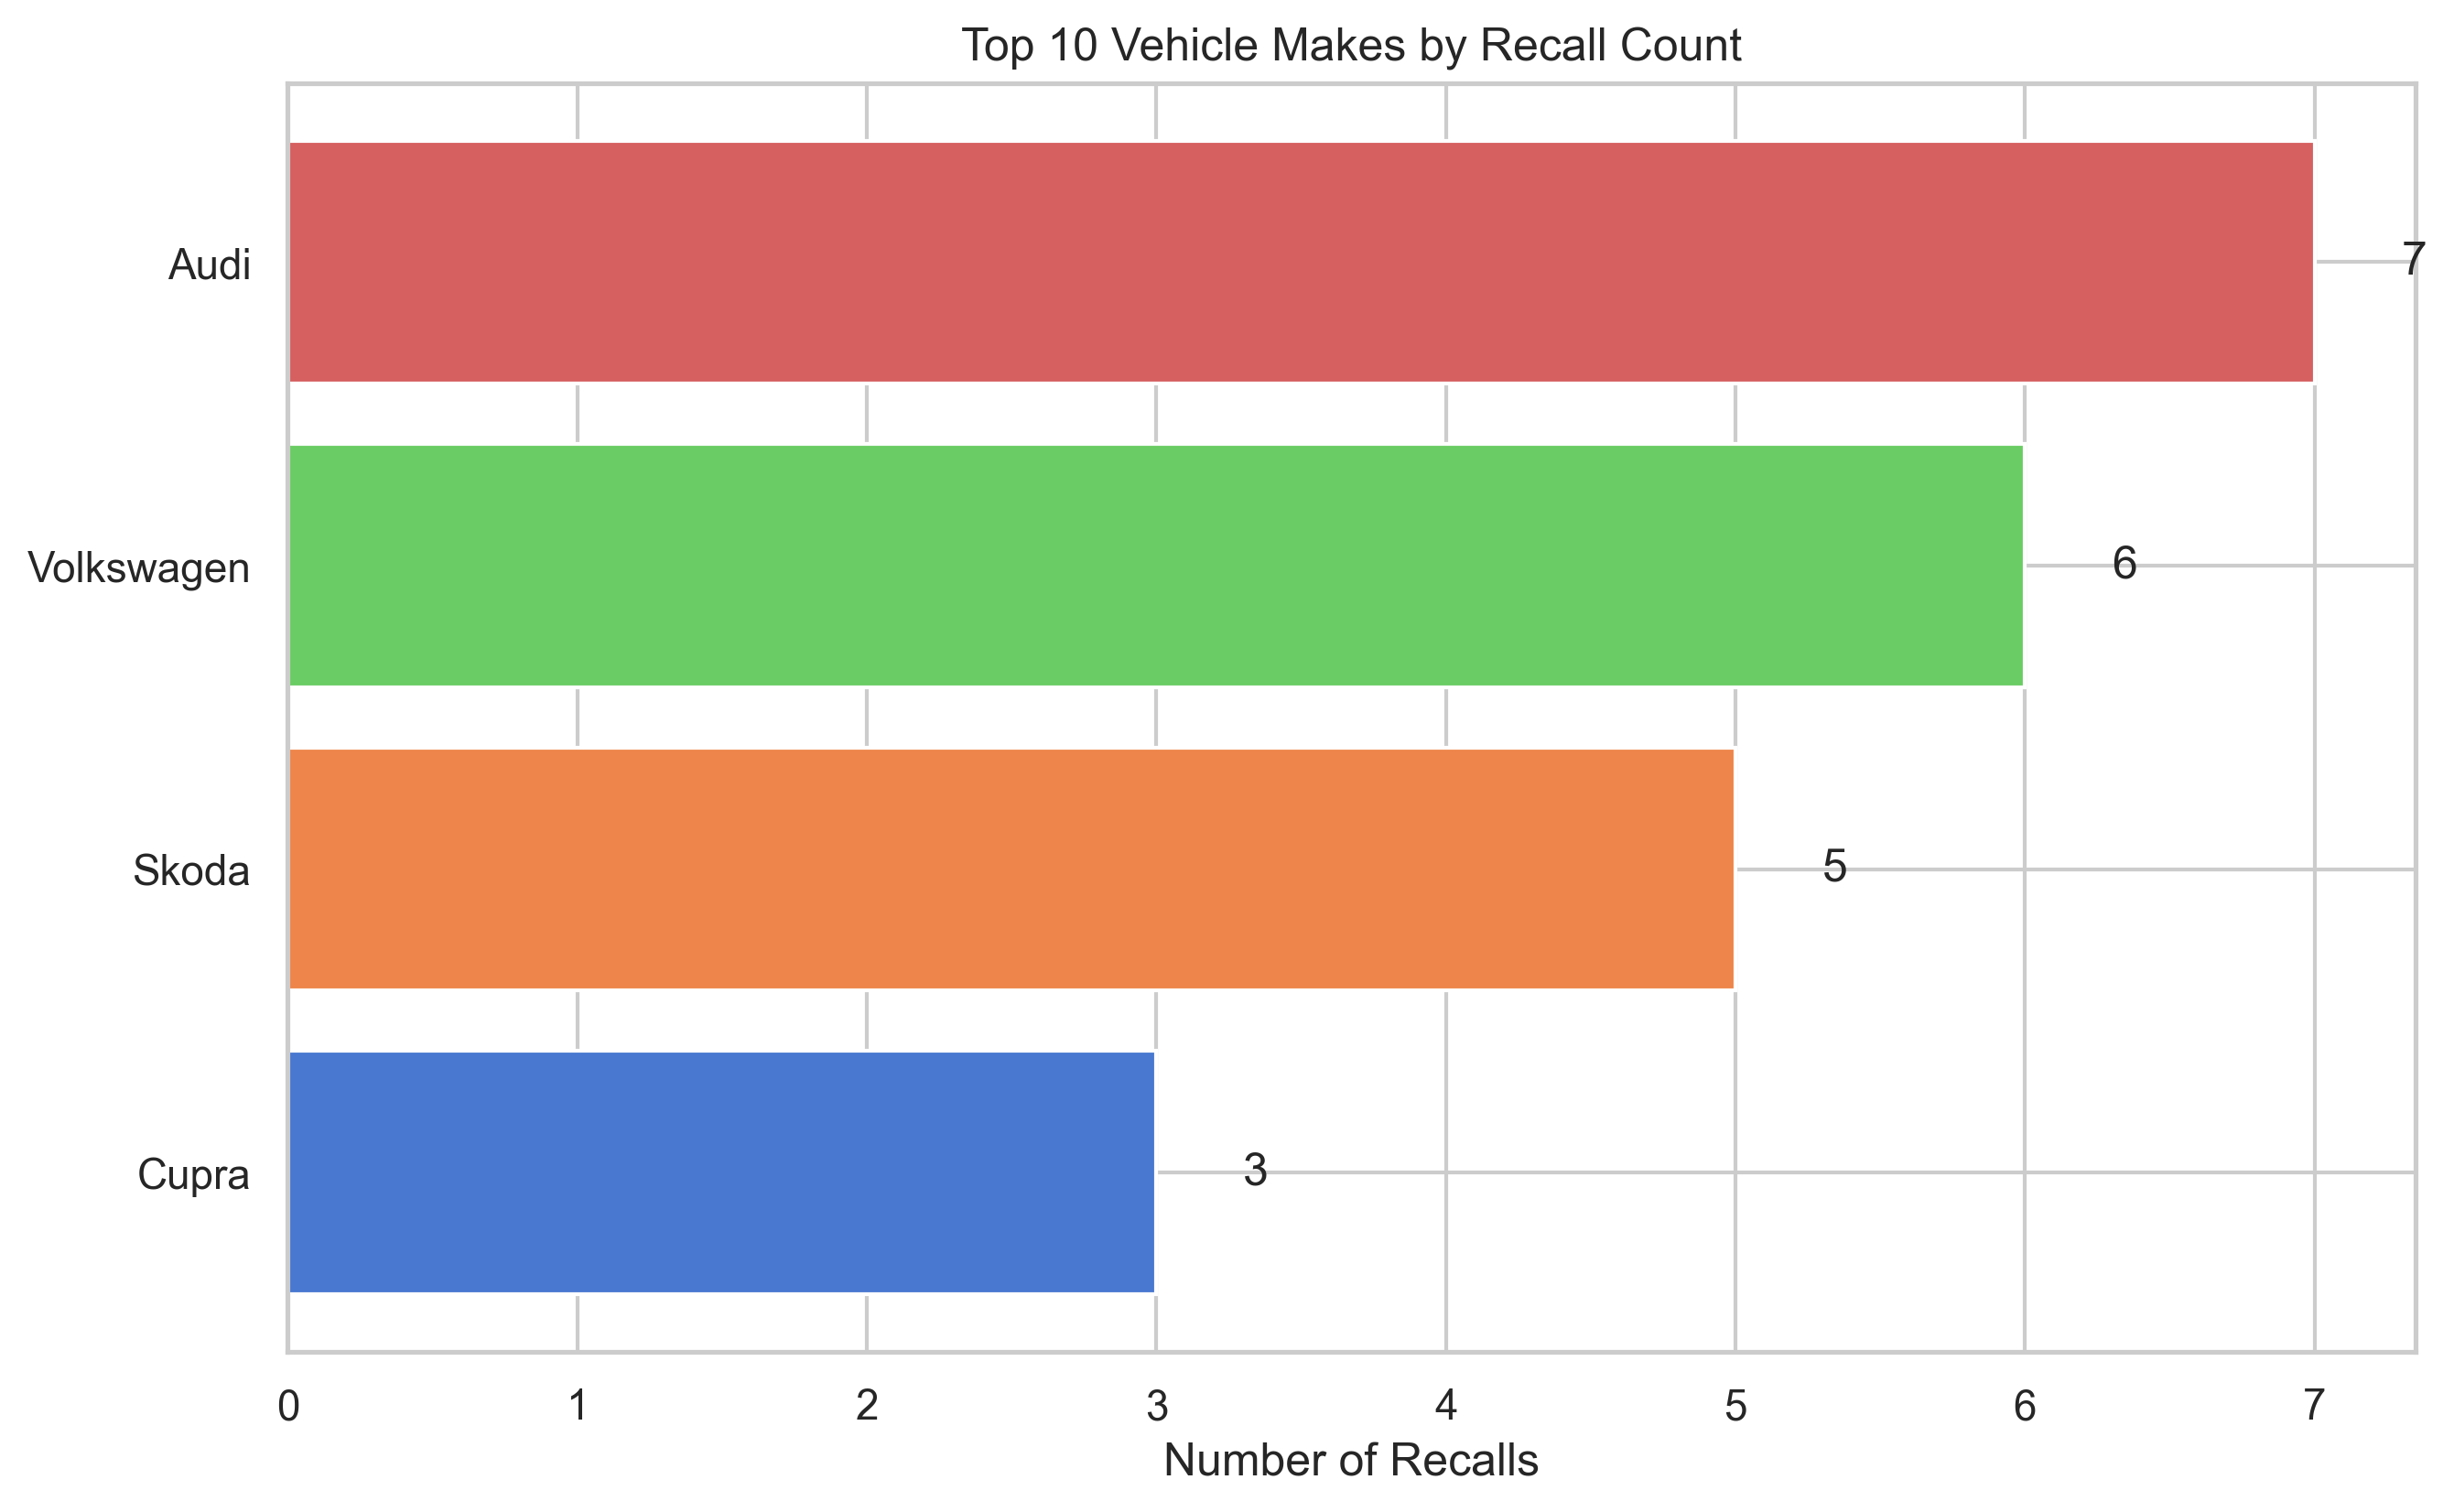

In [2]:
from visualization.static_charts import plot_top_makes_by_recall_count
plot_top_makes_by_recall_count(df, STATIC_DIR)
from IPython.display import Image
Image('../outputs/visualizations/static/top_makes_by_recall_count.png')

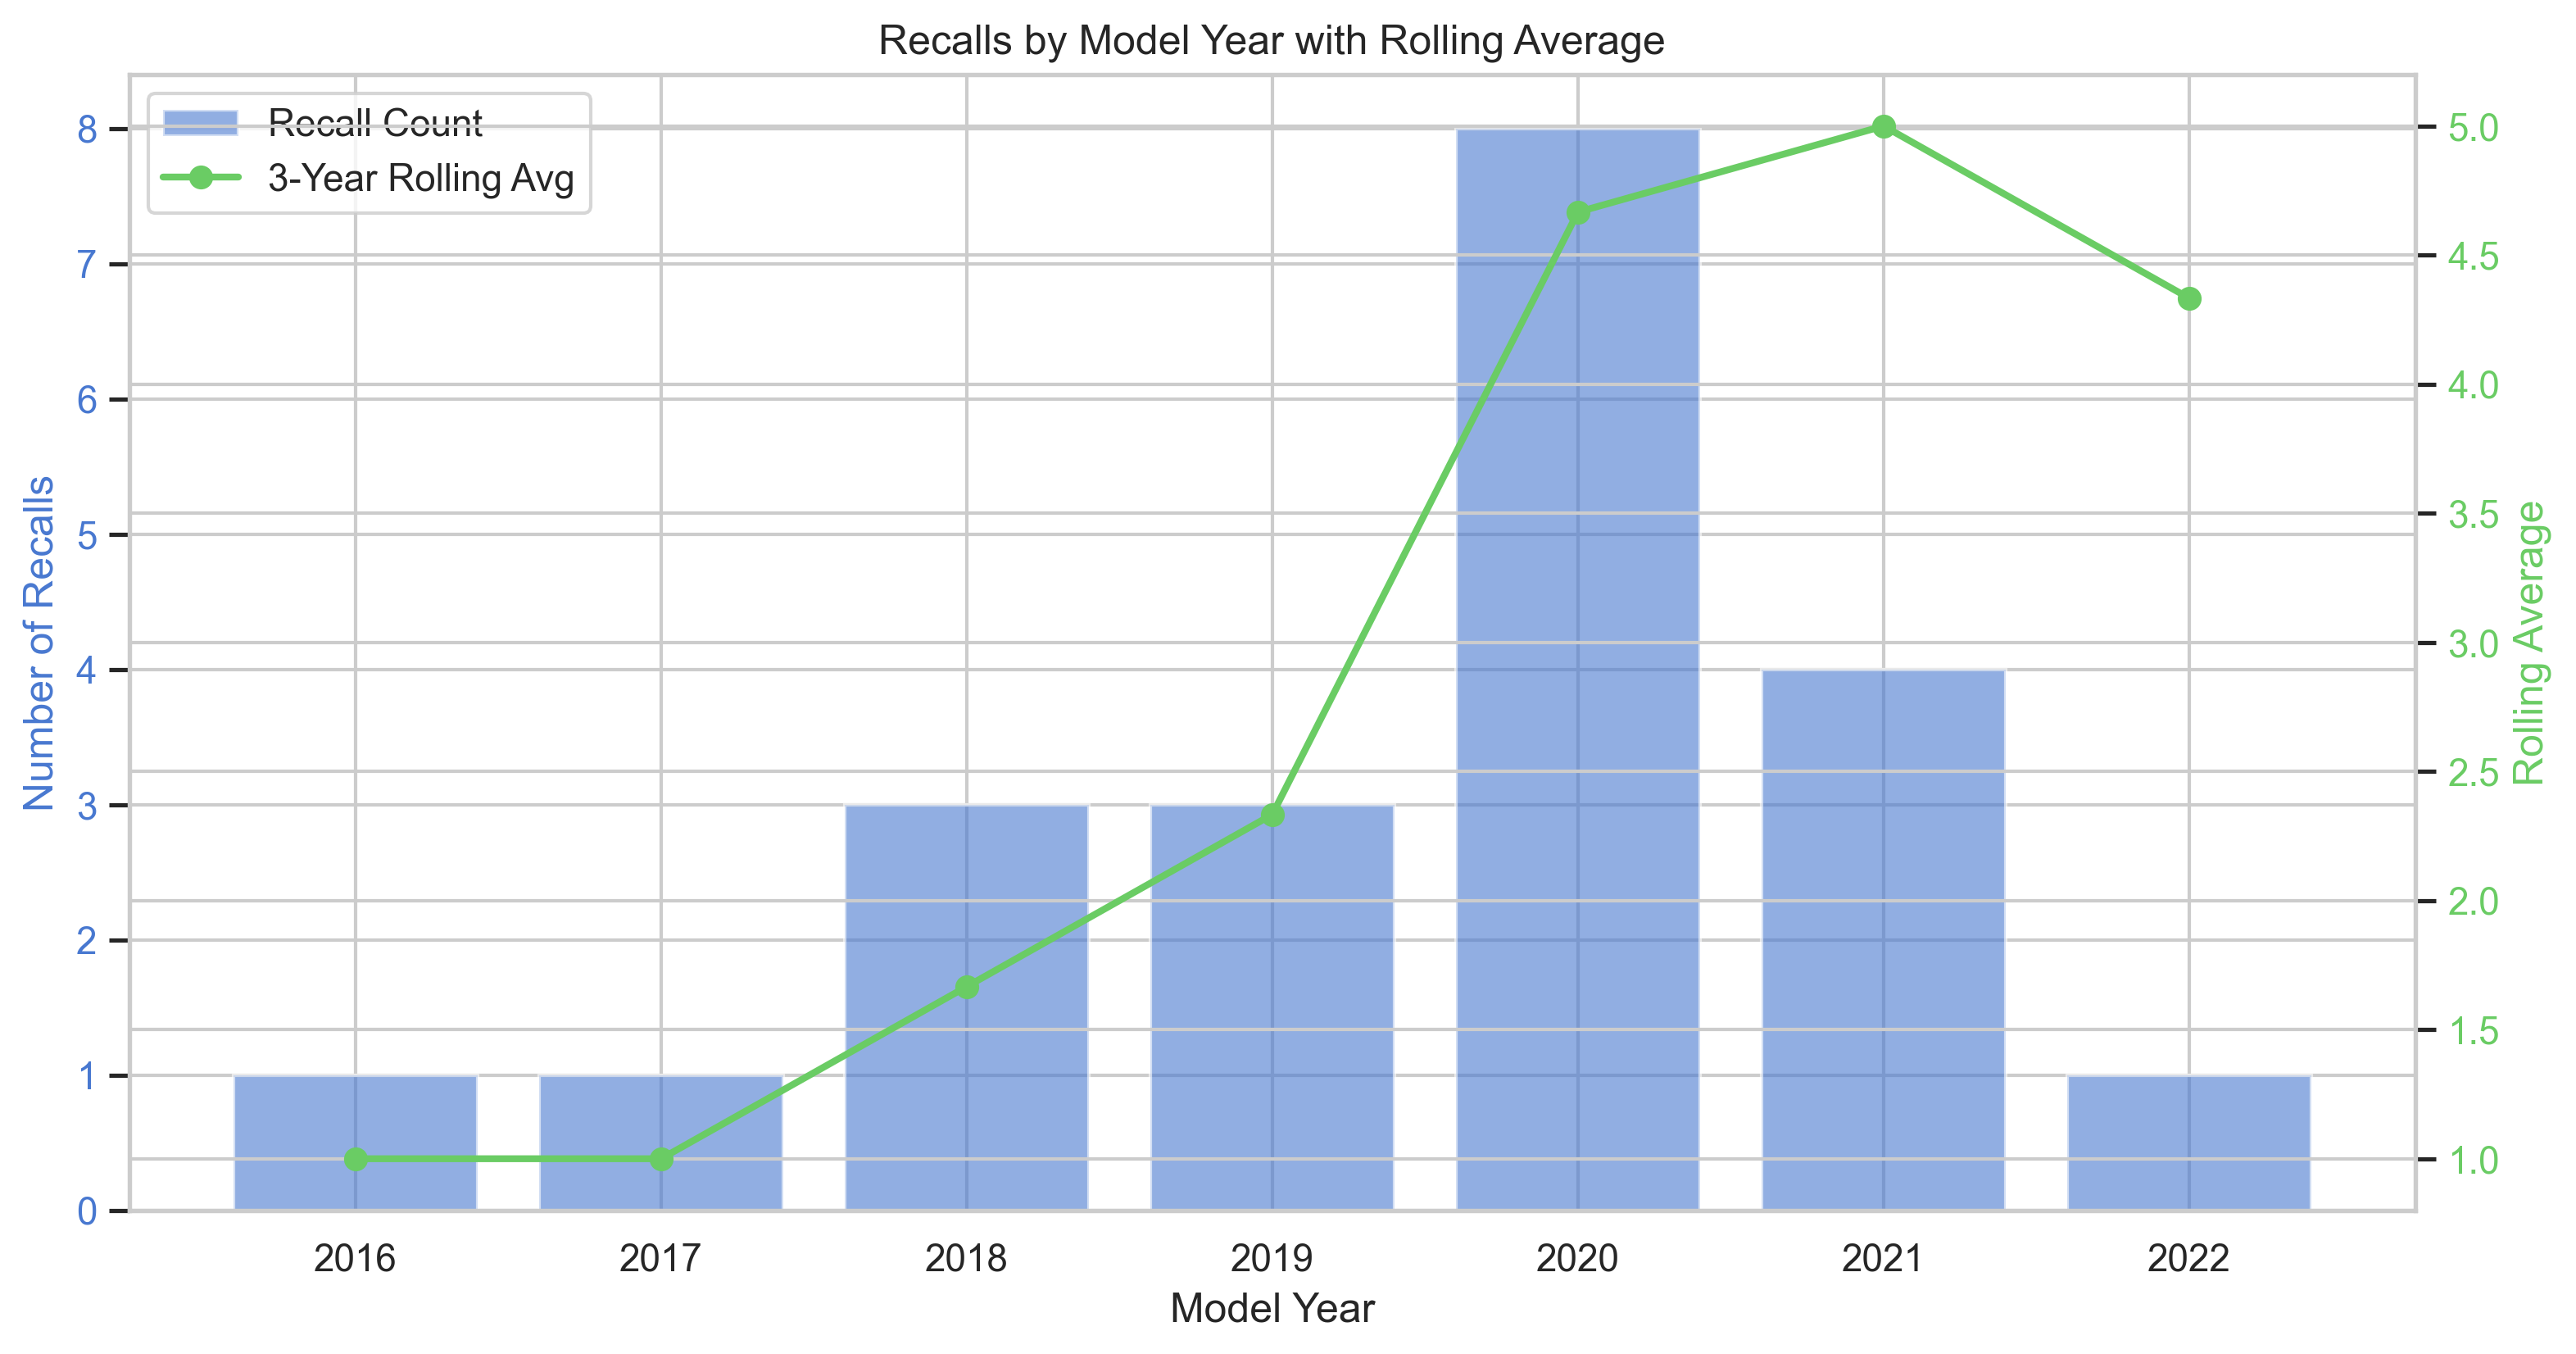

In [3]:
from visualization.static_charts import plot_recalls_over_years
plot_recalls_over_years(df, STATIC_DIR)
Image('../outputs/visualizations/static/recalls_over_years.png')

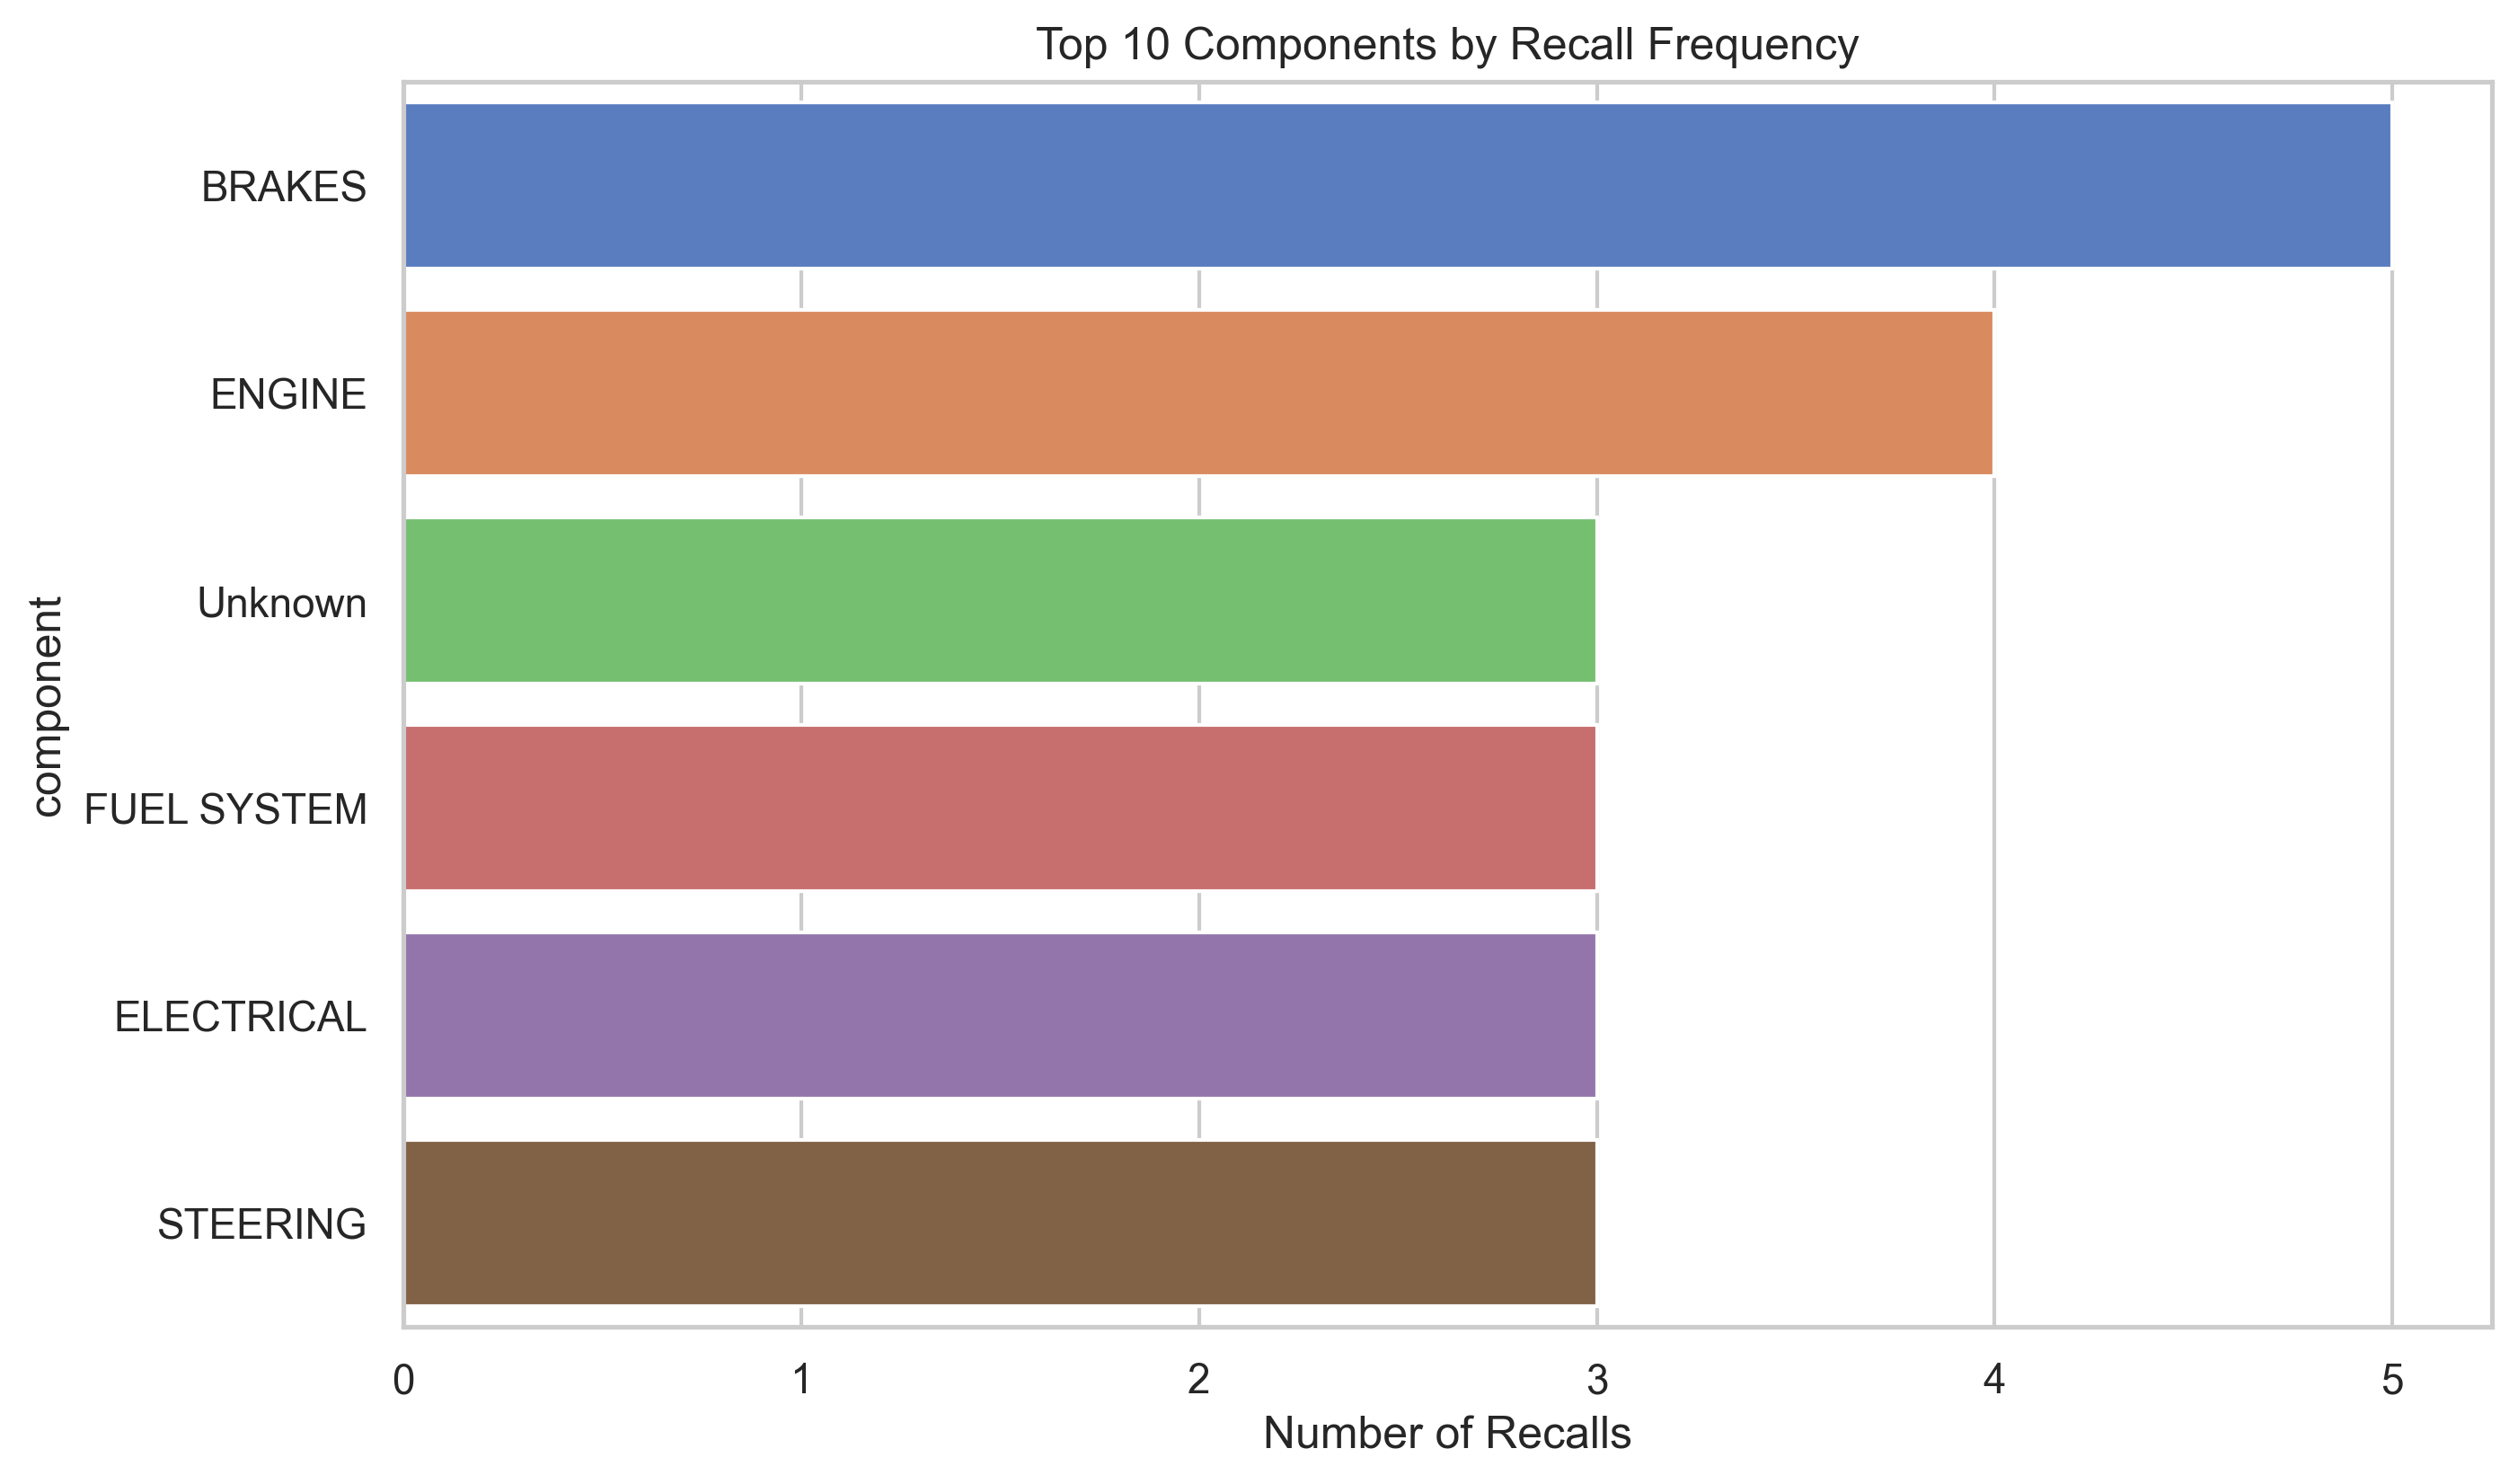

In [4]:
from visualization.static_charts import plot_recall_distribution_by_component
plot_recall_distribution_by_component(df, STATIC_DIR)
Image('../outputs/visualizations/static/recall_distribution_by_component.png')

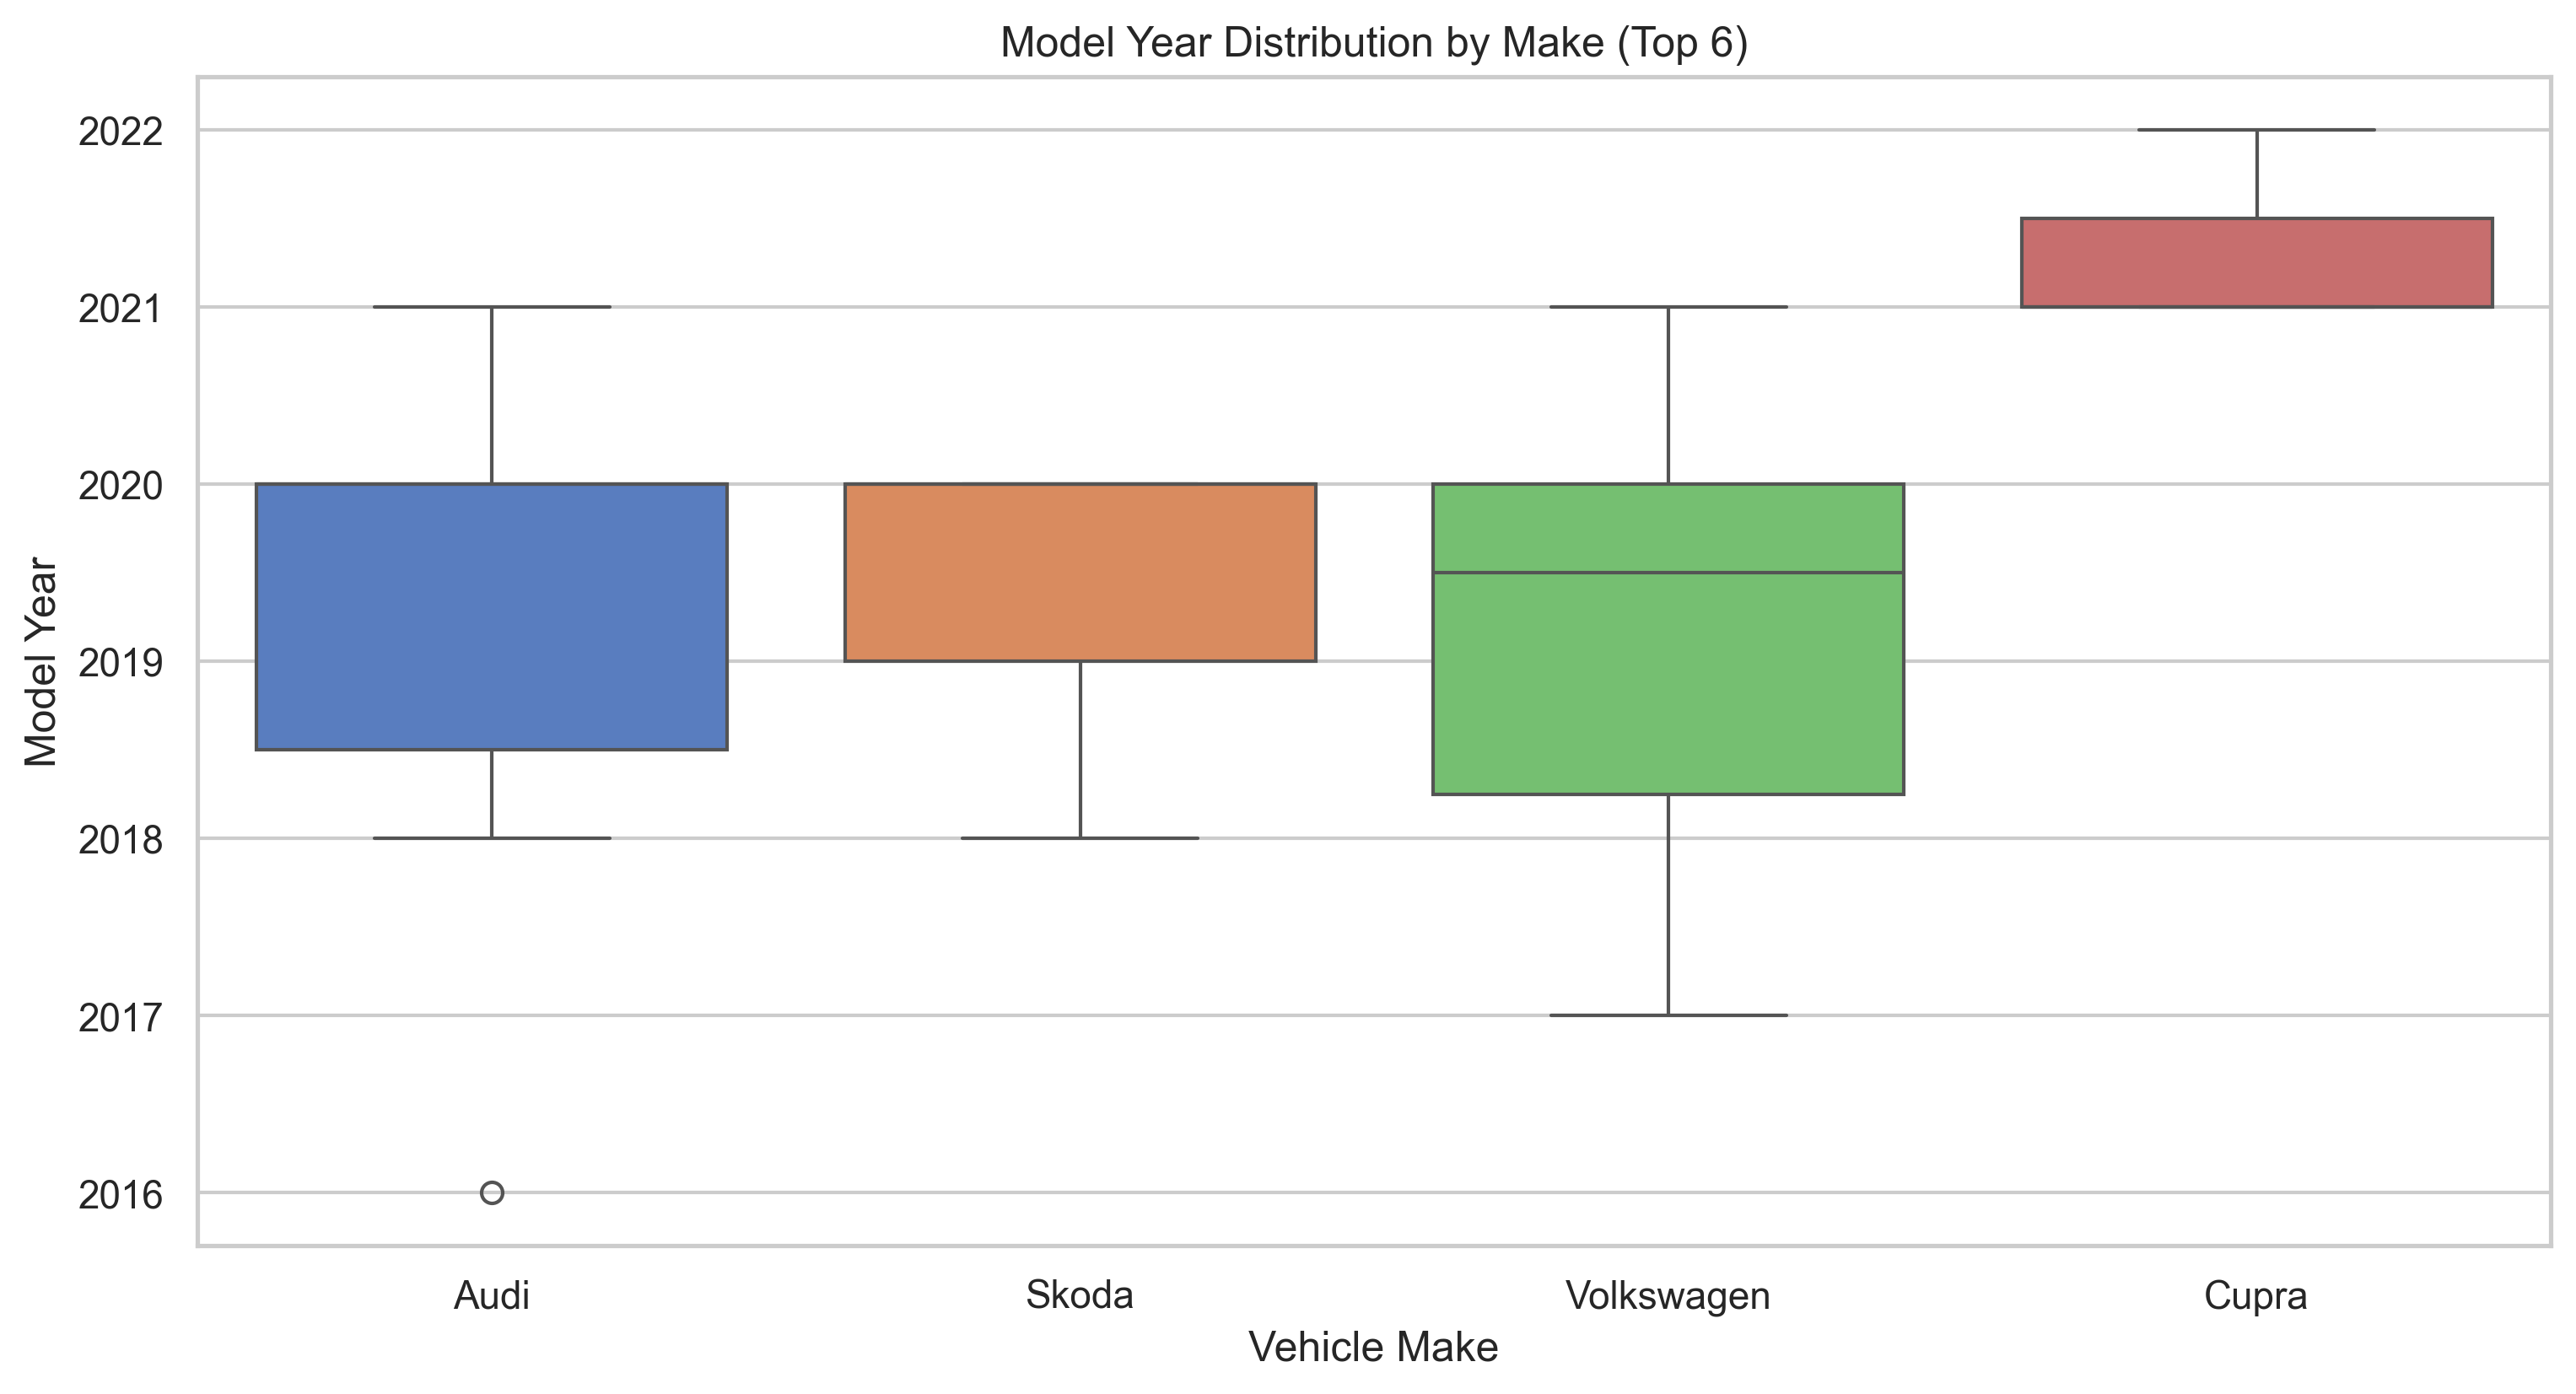

In [5]:
from visualization.static_charts import plot_rating_boxplot_by_make
plot_rating_boxplot_by_make(df, STATIC_DIR)
Image('../outputs/visualizations/static/year_boxplot_by_make.png')

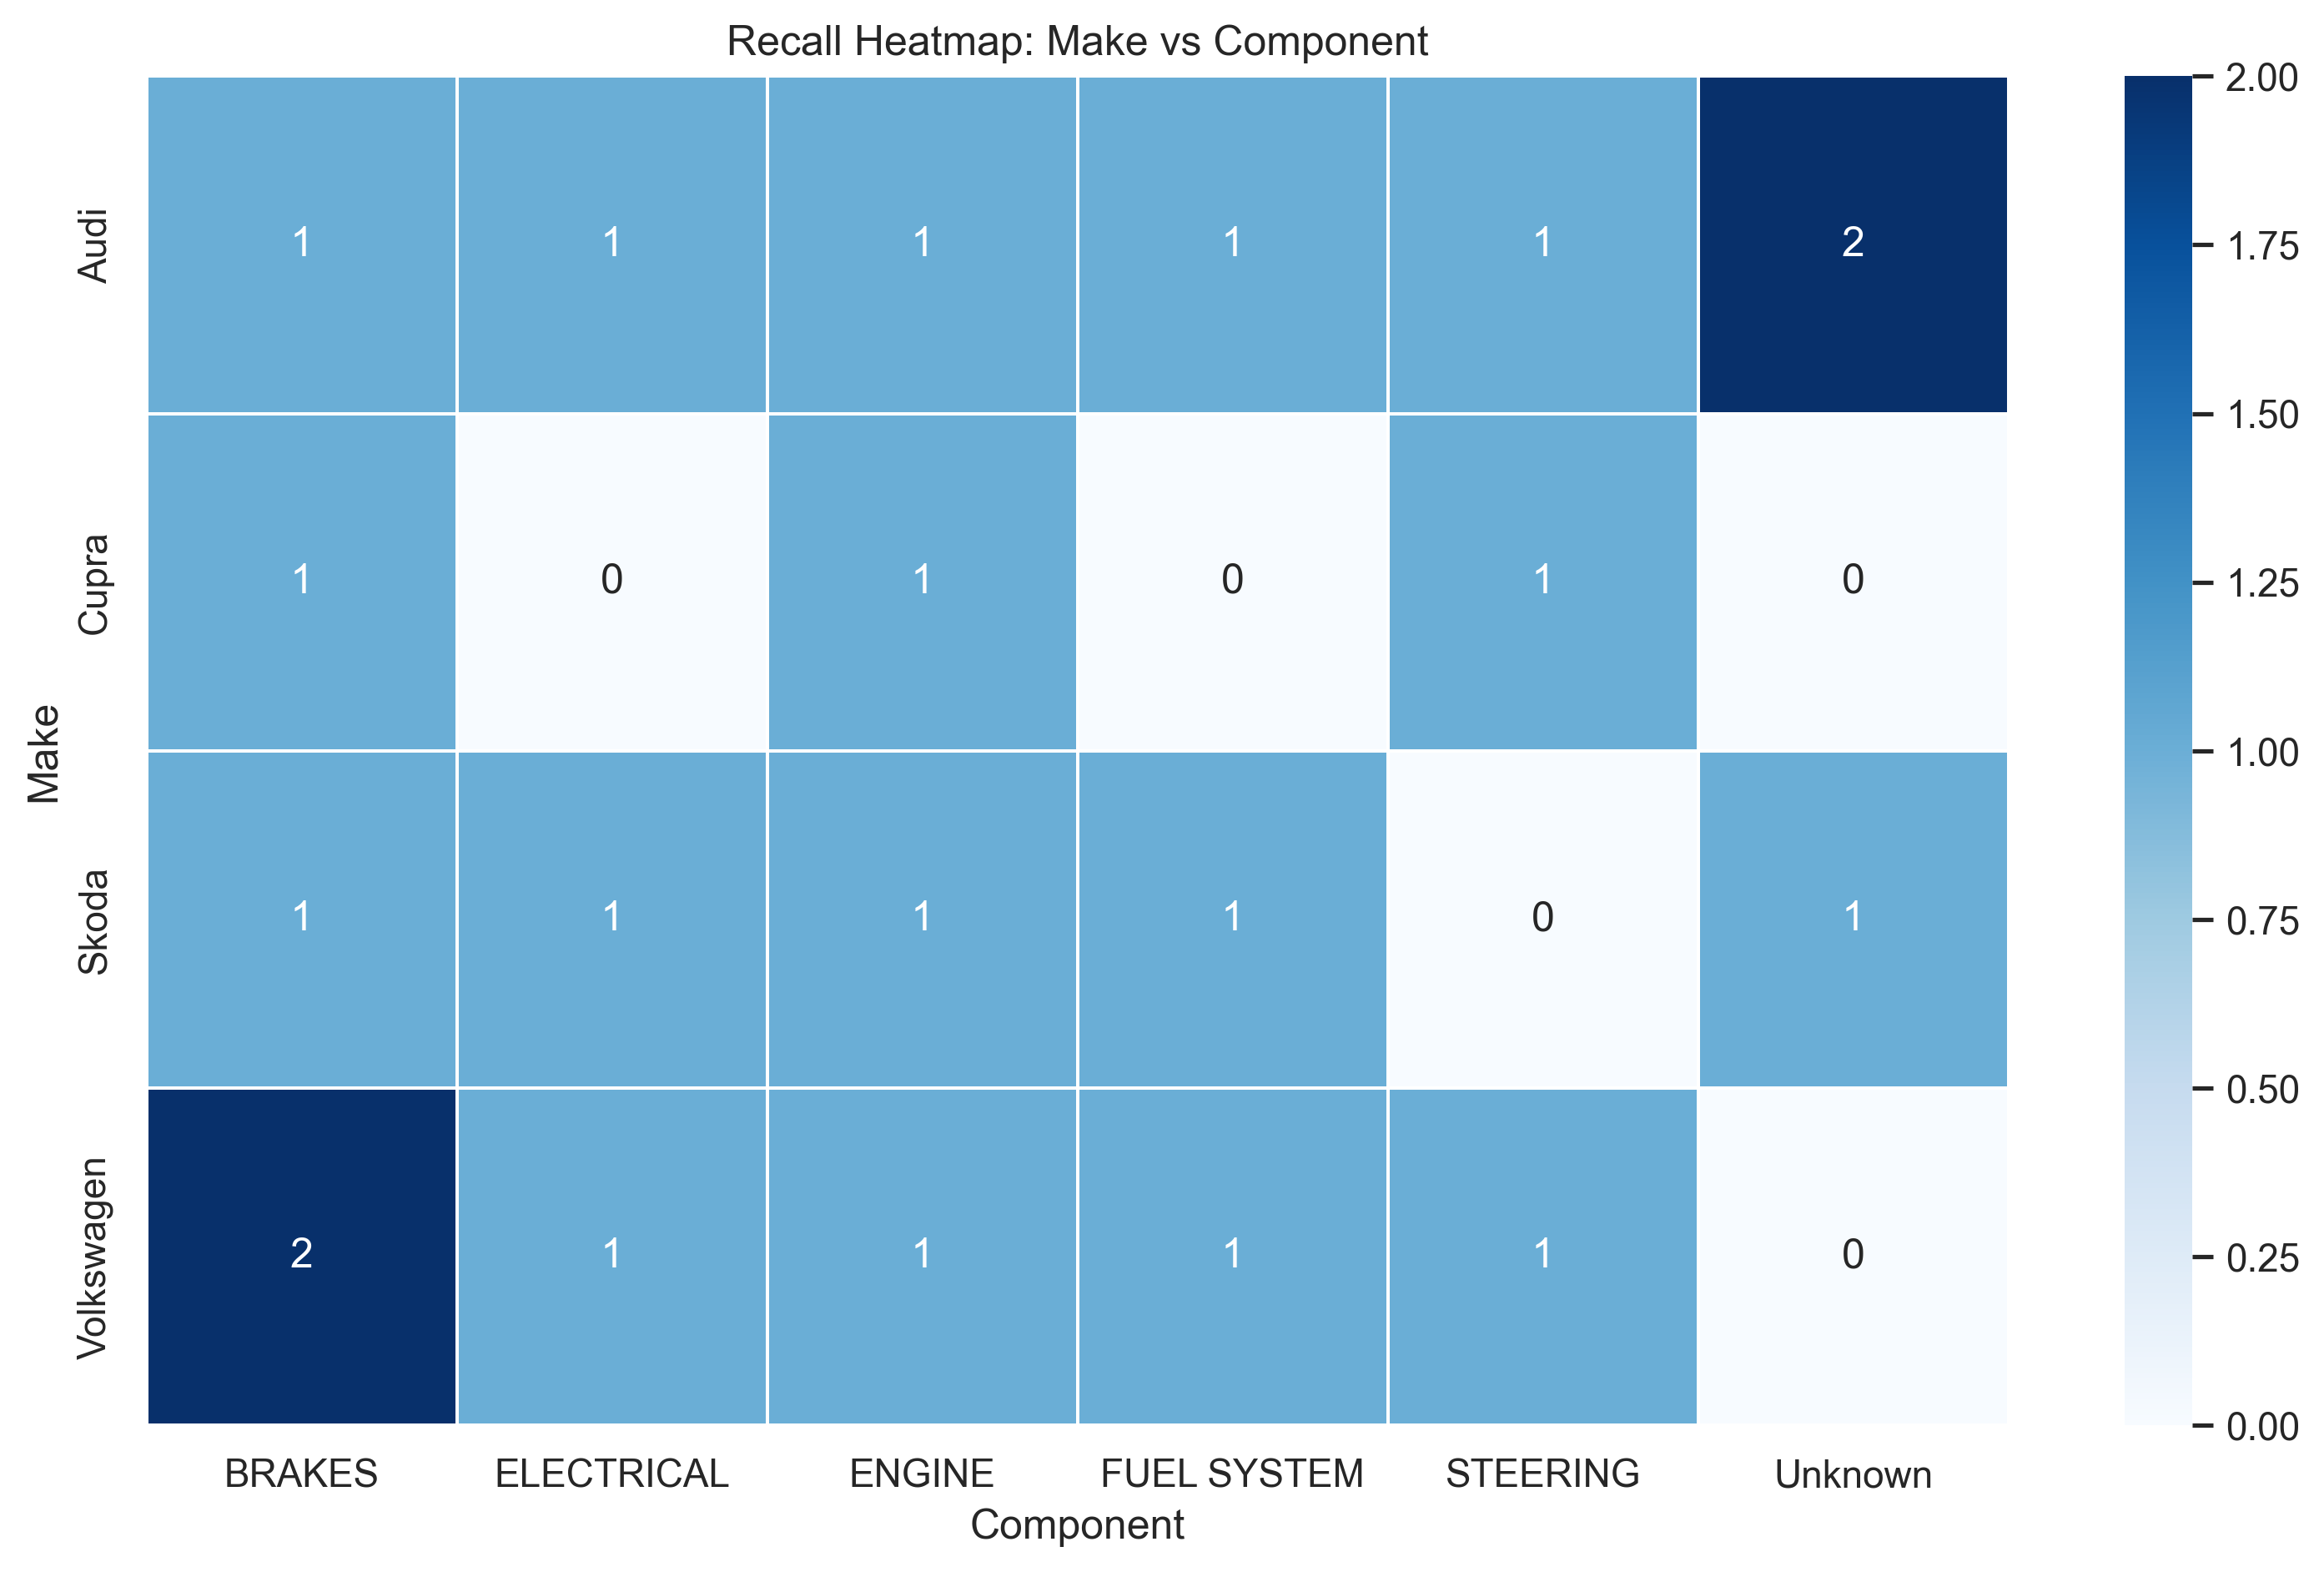

In [6]:
from visualization.static_charts import plot_recall_heatmap
plot_recall_heatmap(df, STATIC_DIR)
Image('../outputs/visualizations/static/recall_heatmap.png')

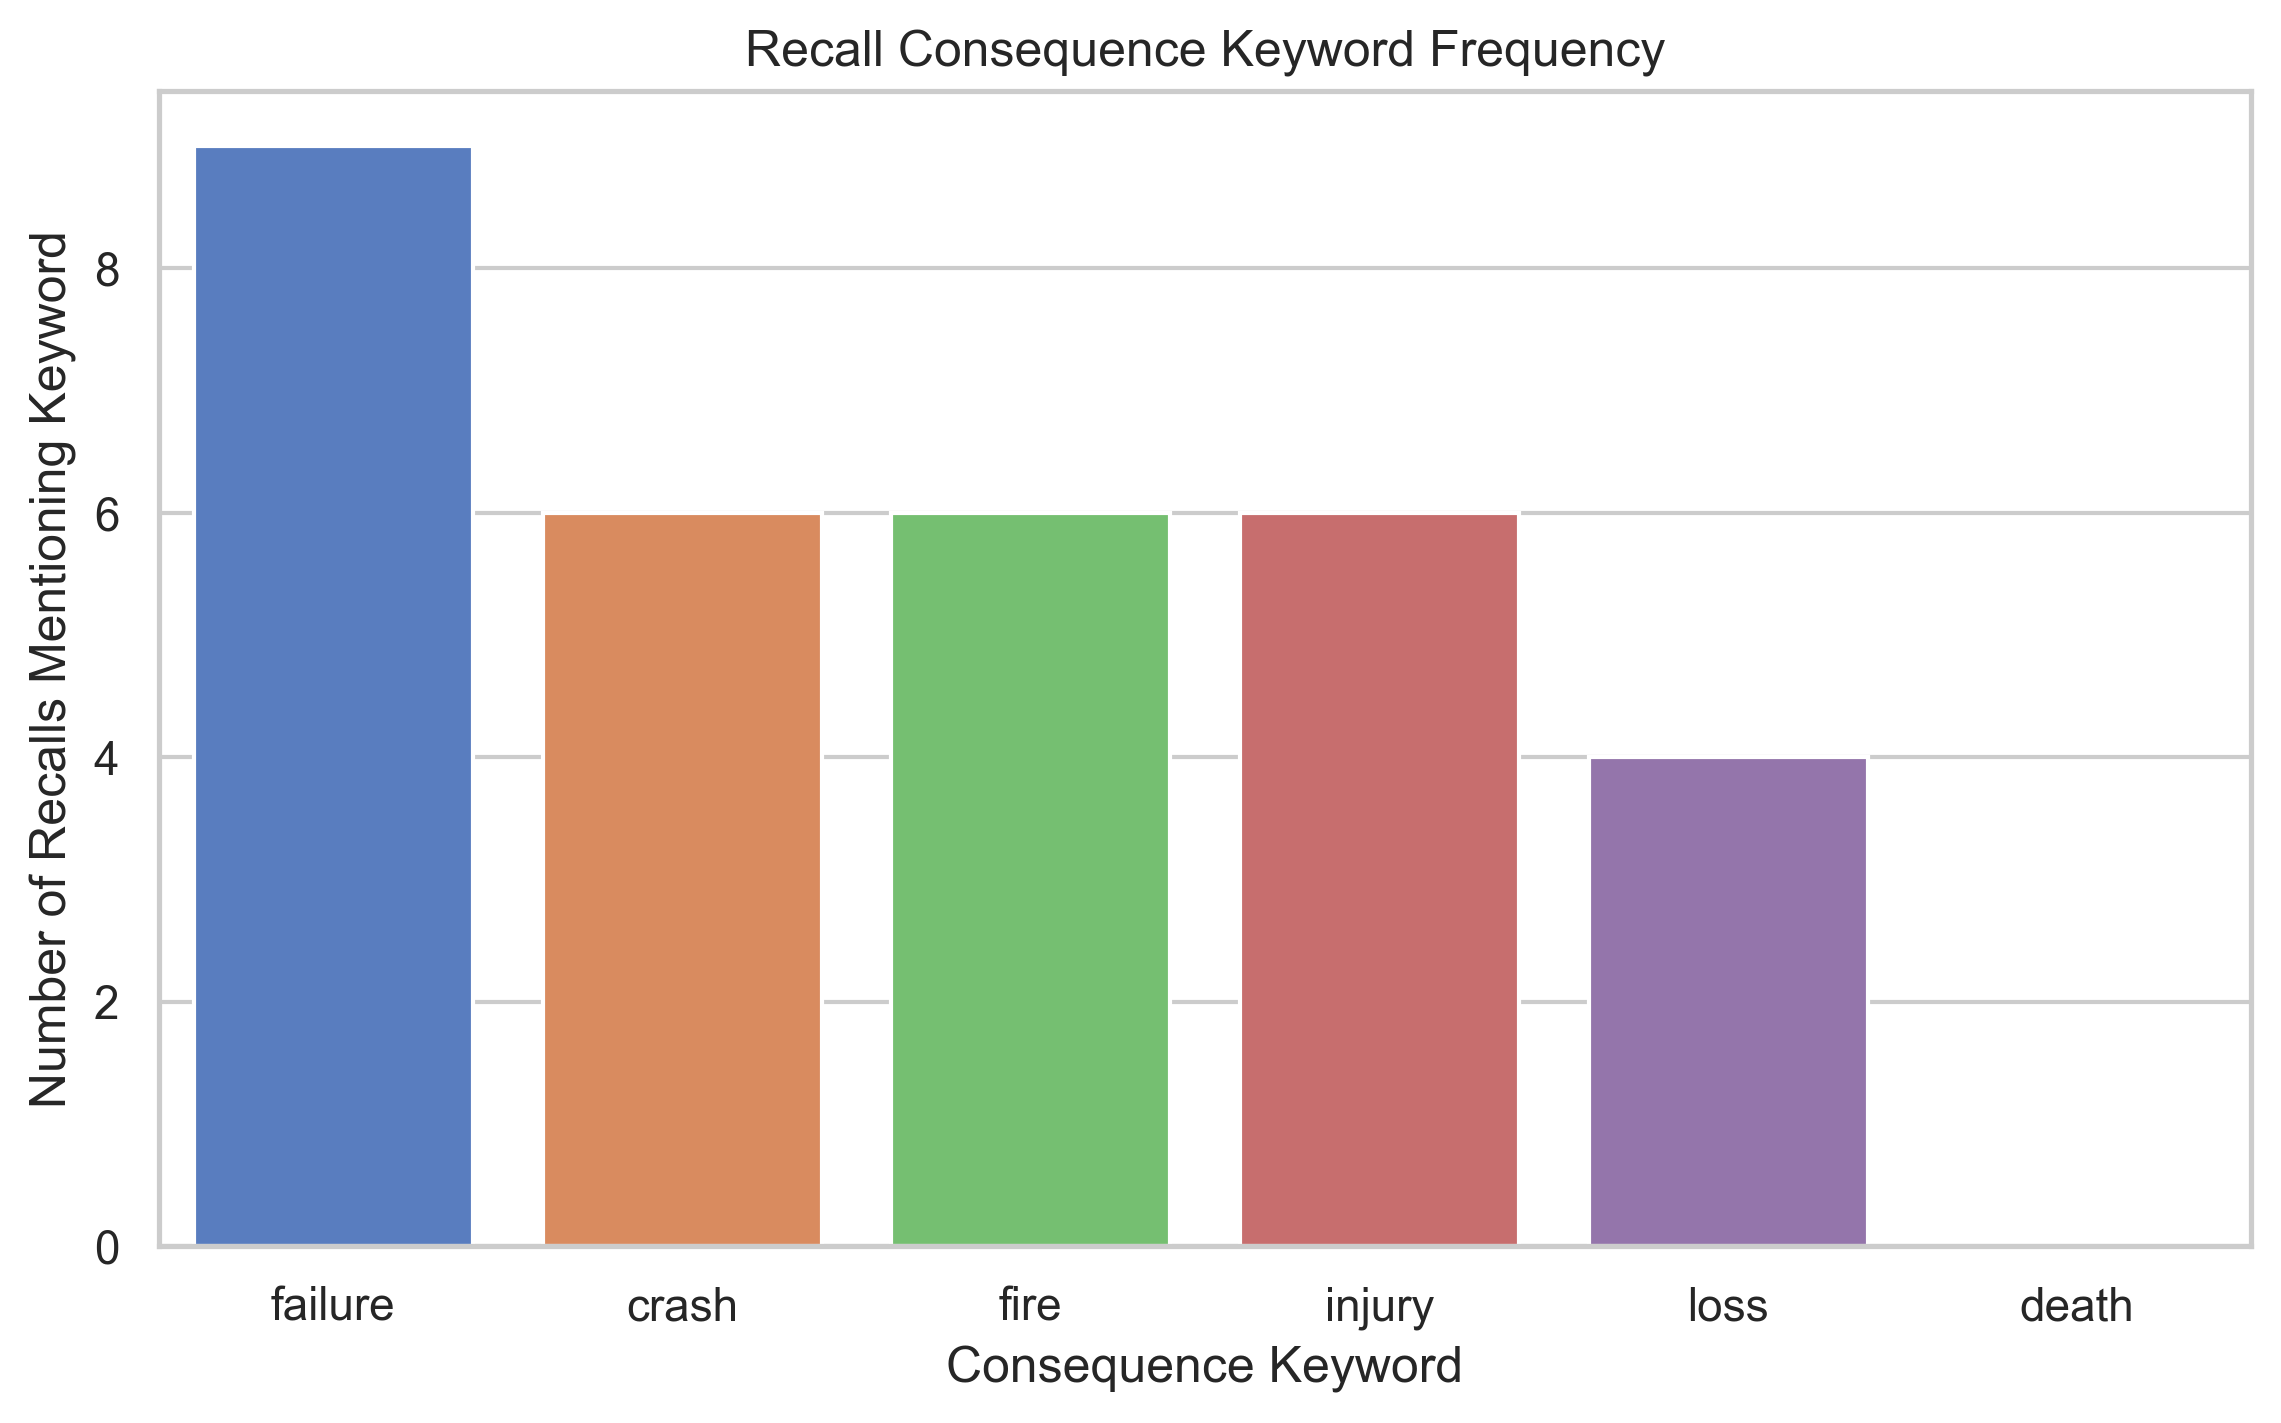

In [7]:
from visualization.static_charts import plot_consequence_distribution
plot_consequence_distribution(df, STATIC_DIR)
Image('../outputs/visualizations/static/consequence_distribution.png')

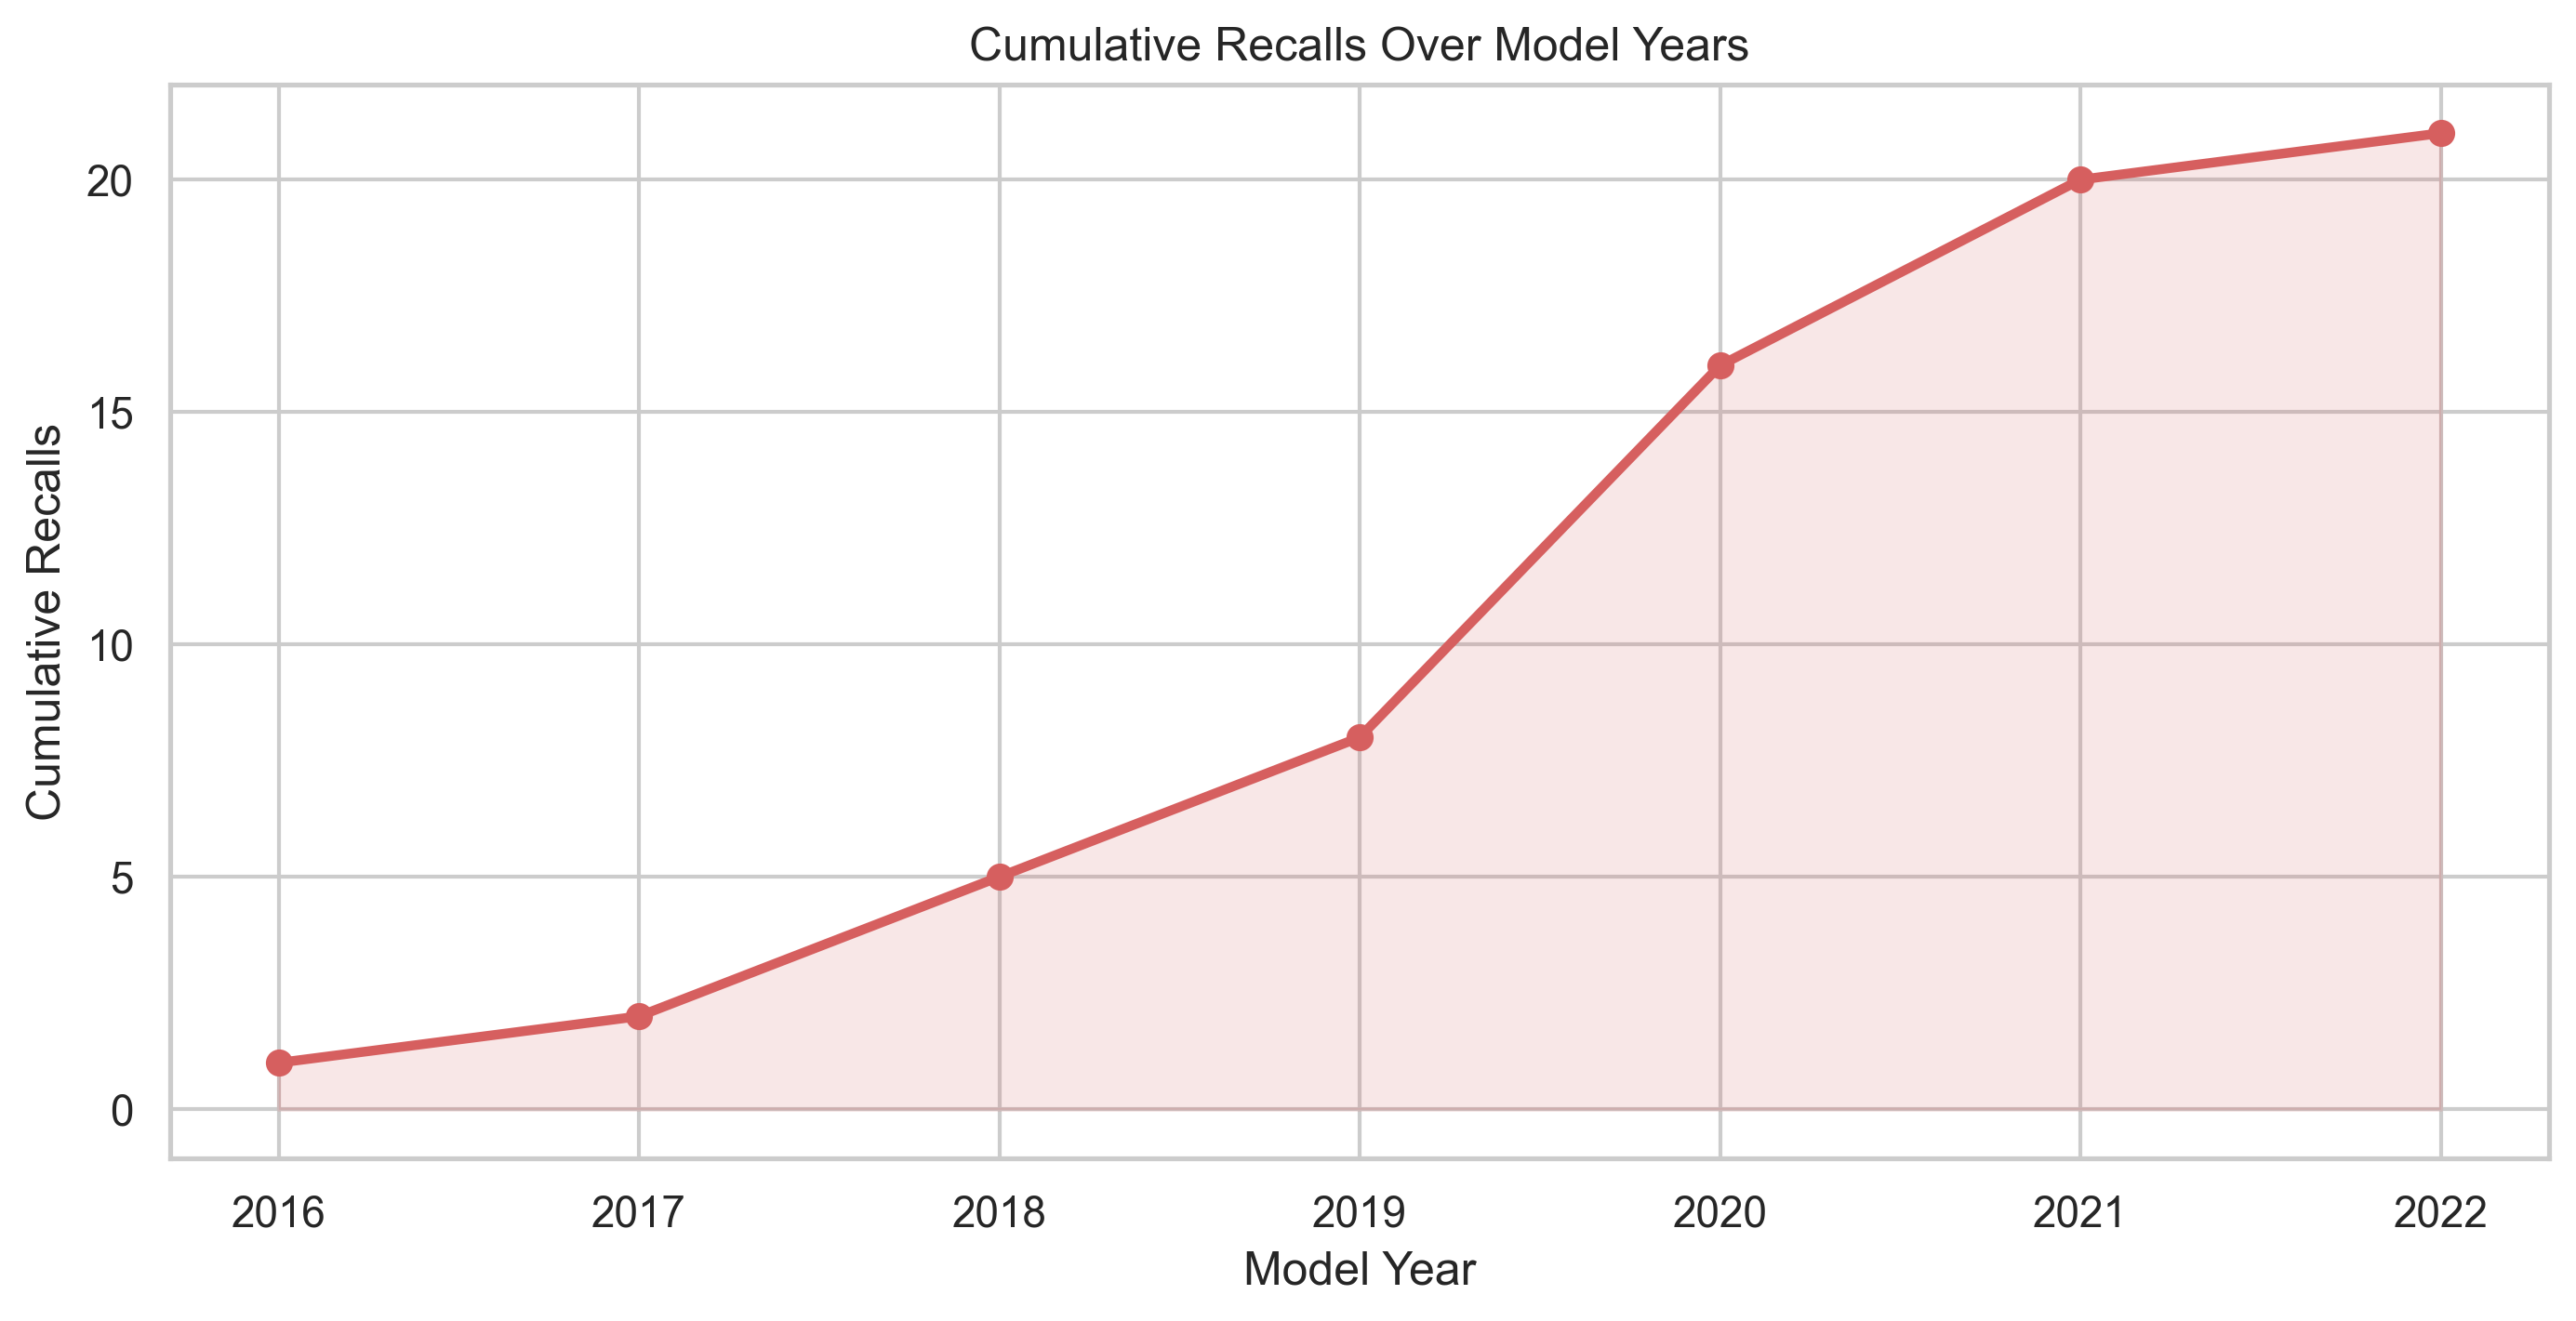

In [8]:
from visualization.static_charts import plot_cumulative_recalls_over_time
plot_cumulative_recalls_over_time(df, STATIC_DIR)
Image('../outputs/visualizations/static/cumulative_recalls_over_time.png')

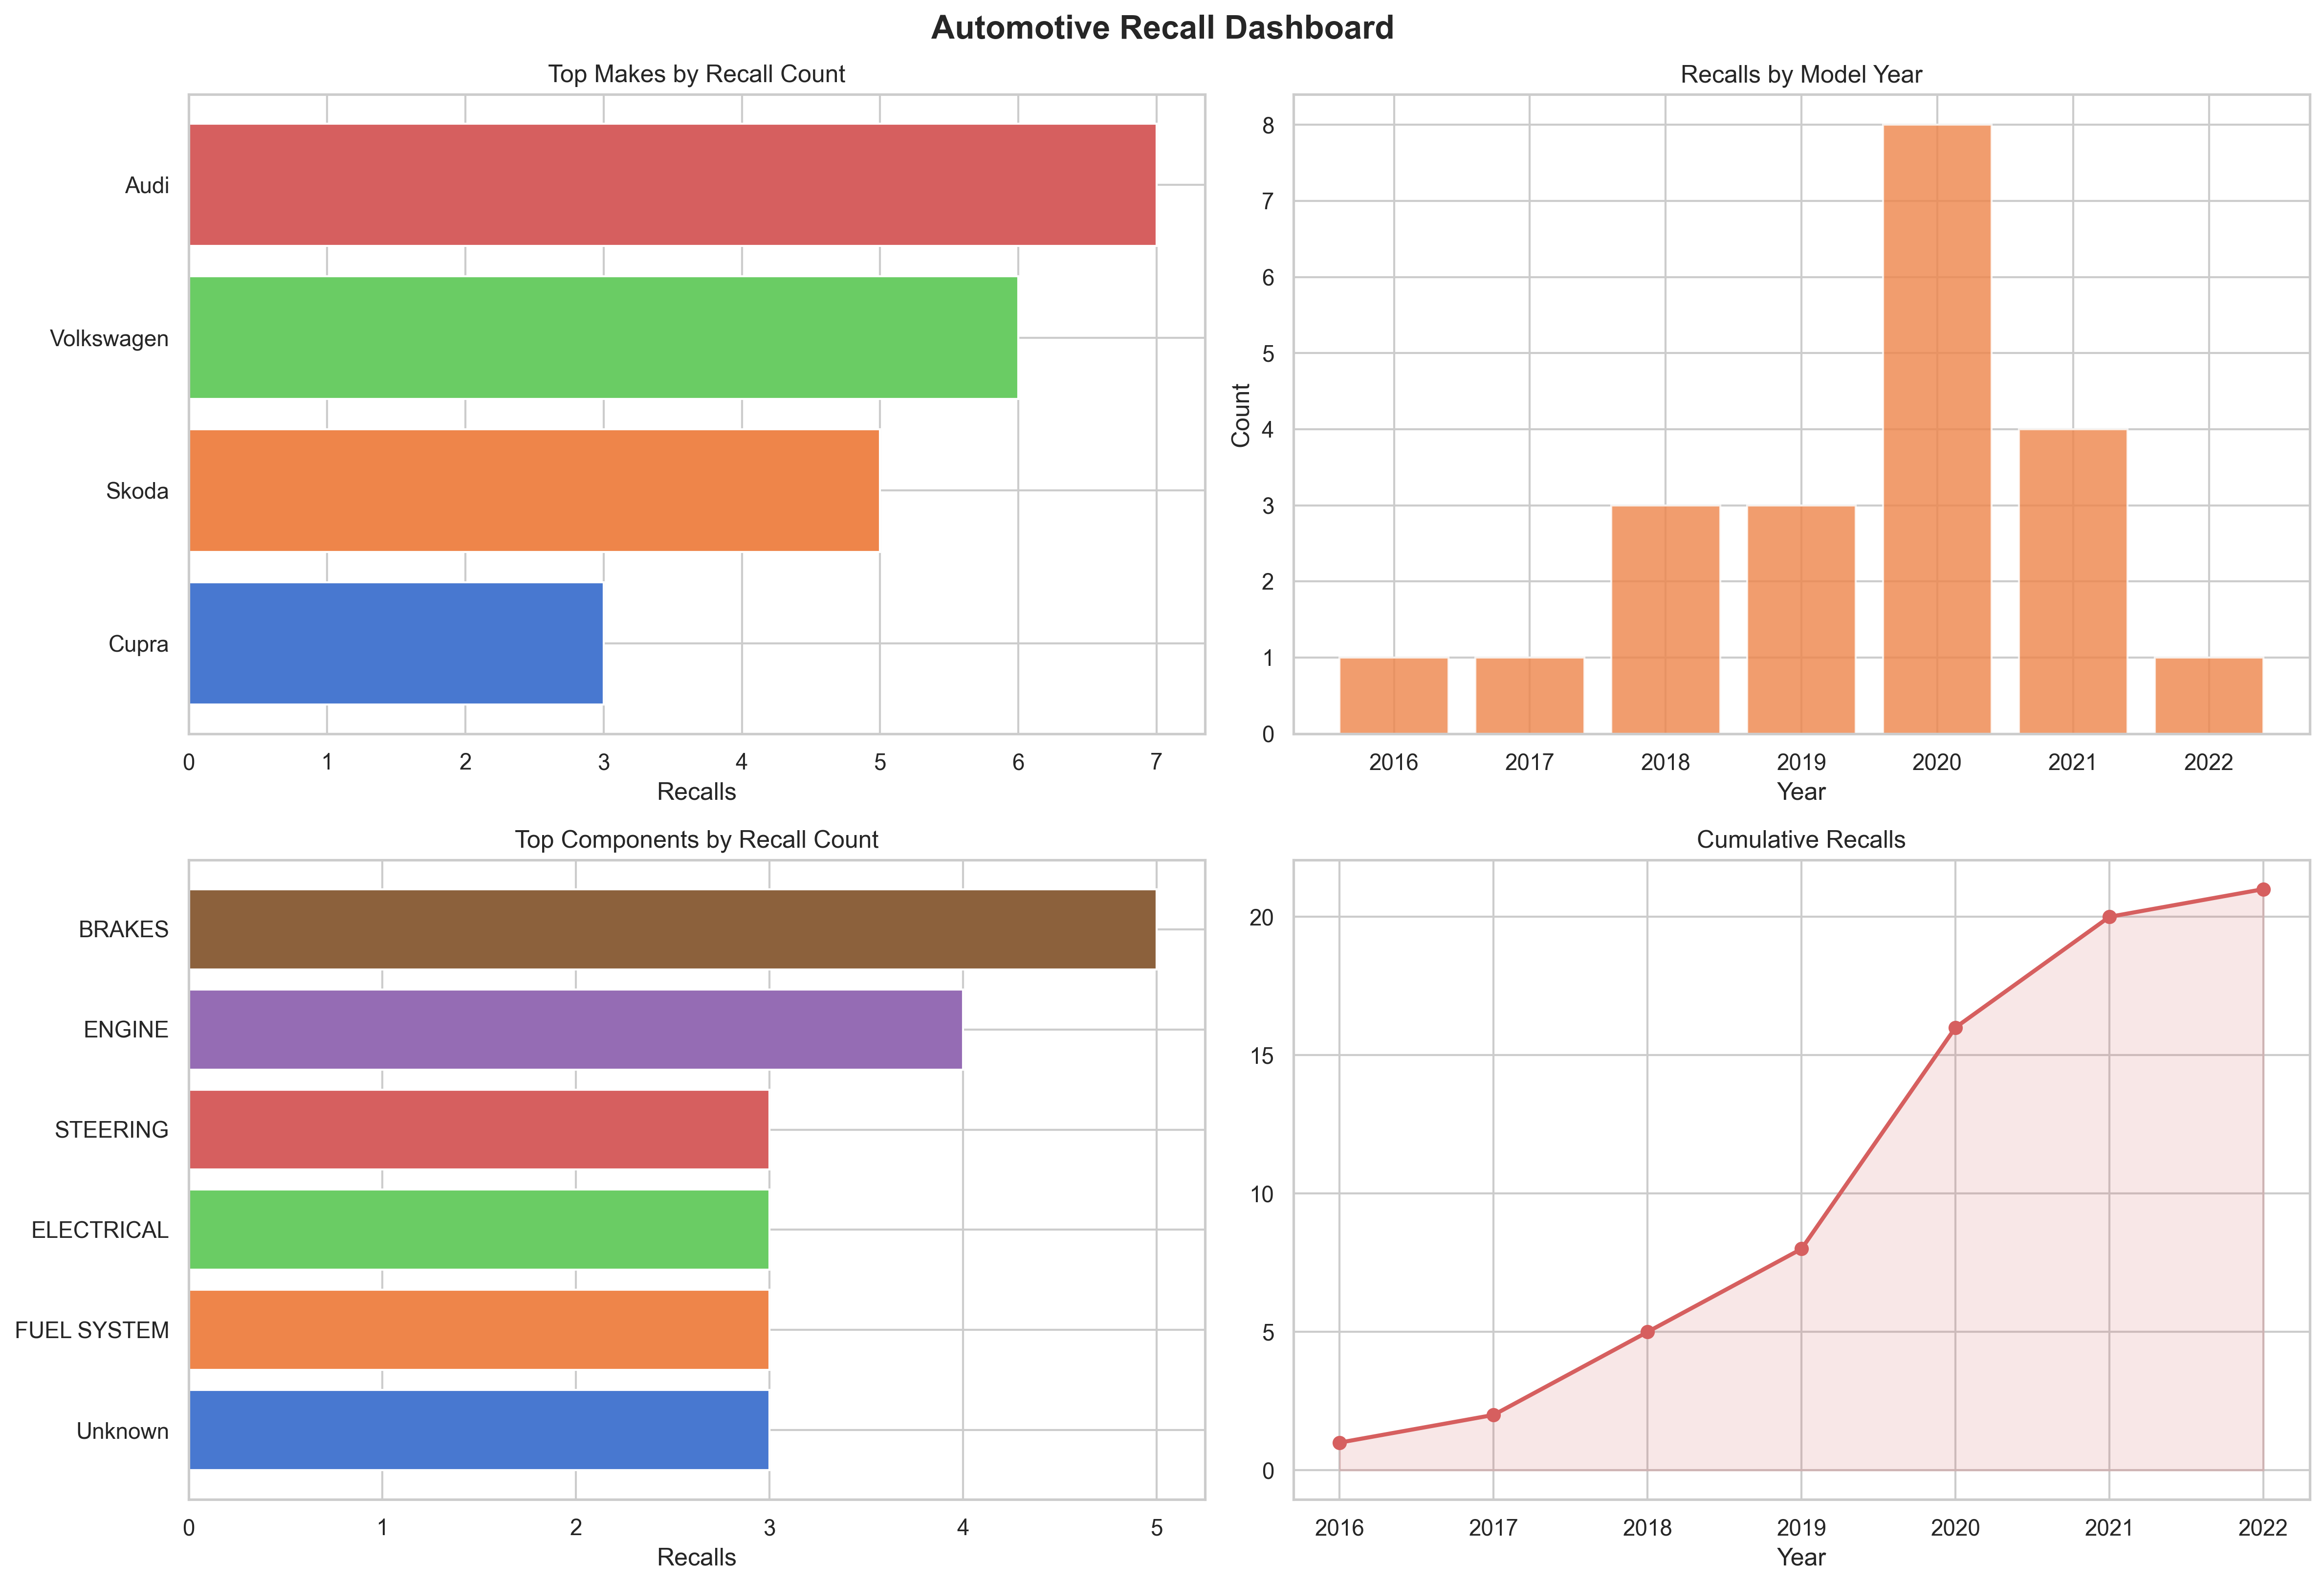

In [9]:
from visualization.static_charts import plot_dashboard_subplots
plot_dashboard_subplots(df, STATIC_DIR)
Image('../outputs/visualizations/static/dashboard_subplots.png')

## Interactive Charts

In [10]:
from visualization.interactive_charts import interactive_recalls_by_make
interactive_recalls_by_make(df, INTERACTIVE_DIR)
counts = df['make'].value_counts().head(15).reset_index()
counts.columns = ['make', 'recall_count']
fig = px.bar(counts, x='recall_count', y='make', orientation='h',
             title='Top 15 Vehicle Makes by Recall Count',
             color='recall_count', color_continuous_scale='Blues')
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, coloraxis_showscale=False)
fig.show()

In [11]:
from visualization.interactive_charts import interactive_recalls_timeline
interactive_recalls_timeline(df, INTERACTIVE_DIR)
df2 = df.copy()
df2['year'] = pd.to_numeric(df2['modelYear'], errors='coerce')
yearly = df2.groupby(['year', 'make']).size().reset_index(name='recall_count').dropna(subset=['year'])
yearly['year'] = yearly['year'].astype(int)
top_makes = df2['make'].value_counts().head(6).index
yearly = yearly[yearly['make'].isin(top_makes)]
fig = px.line(yearly, x='year', y='recall_count', color='make', markers=True,
              title='Recall Trends Over Model Years by Make')
fig.show()

In [12]:
from visualization.interactive_charts import interactive_component_treemap
interactive_component_treemap(df, INTERACTIVE_DIR)
top_makes = df['make'].value_counts().head(6).index
filtered = df[df['make'].isin(top_makes)]
grouped = filtered.groupby(['make', 'component']).size().reset_index(name='recall_count')
fig = px.treemap(grouped, path=['make', 'component'], values='recall_count',
                 title='Recall Distribution: Make and Component',
                 color='recall_count', color_continuous_scale='Blues')
fig.show()

In [13]:
from visualization.interactive_charts import interactive_scatter_year_vs_count
interactive_scatter_year_vs_count(df, INTERACTIVE_DIR)
df3 = df.copy()
df3['year'] = pd.to_numeric(df3['modelYear'], errors='coerce')
grouped = df3.groupby(['year', 'make']).size().reset_index(name='recall_count').dropna(subset=['year'])
grouped['year'] = grouped['year'].astype(int)
top_makes = df3['make'].value_counts().head(8).index
grouped = grouped[grouped['make'].isin(top_makes)]
fig = px.scatter(grouped, x='year', y='recall_count', color='make', size='recall_count',
                 title='Model Year vs Recall Count per Make')
fig.show()

In [14]:
from visualization.interactive_charts import interactive_multi_layout
interactive_multi_layout(df, INTERACTIVE_DIR)
from plotly.subplots import make_subplots
import plotly.graph_objects as go
df4 = df.copy()
df4['year'] = pd.to_numeric(df4['modelYear'], errors='coerce')
make_counts = df4['make'].value_counts().head(10)
yearly = df4.groupby('year').size().reset_index(name='count').dropna(subset=['year'])
yearly['year'] = yearly['year'].astype(int)
comp_counts = df4['component'].value_counts().head(10)
yearly_sorted = yearly.sort_values('year')
yearly_sorted = yearly_sorted.copy()
yearly_sorted['cumulative'] = yearly_sorted['count'].cumsum()
fig = make_subplots(rows=2, cols=2, subplot_titles=['Top Makes', 'Recalls by Year', 'Top Components', 'Cumulative'])
fig.add_trace(go.Bar(x=make_counts.values, y=make_counts.index, orientation='h', marker_color='steelblue'), row=1, col=1)
fig.add_trace(go.Bar(x=yearly['year'], y=yearly['count'], marker_color='cornflowerblue'), row=1, col=2)
fig.add_trace(go.Bar(x=comp_counts.values, y=comp_counts.index, orientation='h', marker_color='mediumpurple'), row=2, col=1)
fig.add_trace(go.Scatter(x=yearly_sorted['year'], y=yearly_sorted['cumulative'], mode='lines+markers', line={'color': 'tomato'}), row=2, col=2)
fig.update_layout(height=800, title_text='Automotive Recall Interactive Dashboard', showlegend=False)
fig.show()

## Automated Chart Generation

In [15]:
from visualization.chart_generator import run_all_charts
run_all_charts()
print('Static files:', os.listdir('../outputs/visualizations/static'))
print('Interactive files:', os.listdir('../outputs/visualizations/interactive'))

2026-05-22 22:59:40,564 - INFO - Loading dataset from /Users/elmedin.karisiksystemverification.com/Documents/private/Automotive-Industry-Tracker/data/processed/cleaned/cleaned_data.csv
2026-05-22 22:59:40,567 - INFO - Loaded 21 records after filtering
2026-05-22 22:59:40,567 - INFO - Generating 8 static charts
2026-05-22 22:59:40,568 - INFO -   Generating: Top Makes by Recall Count
2026-05-22 22:59:40,728 - INFO -   Generating: Recalls Over Years
2026-05-22 22:59:41,055 - INFO -   Generating: Recall Distribution by Component
2026-05-22 22:59:41,232 - INFO -   Generating: Year Boxplot by Make
2026-05-22 22:59:41,412 - INFO -   Generating: Recall Heatmap
2026-05-22 22:59:41,655 - INFO -   Generating: Consequence Distribution
2026-05-22 22:59:41,818 - INFO -   Generating: Cumulative Recalls Over Time
2026-05-22 22:59:42,003 - INFO -   Generating: Dashboard Subplots
2026-05-22 22:59:42,707 - INFO - Static charts saved to /Users/elmedin.karisiksystemverification.com/Documents/private/Automo

Static files: ['dashboard_subplots.pdf', 'cumulative_recalls_over_time.png', 'dashboard_subplots.png', 'cumulative_recalls_over_time.pdf', 'recall_heatmap.png', 'recall_heatmap.pdf', 'consequence_distribution.pdf', 'recall_distribution_by_component.pdf', 'recalls_over_years.png', 'recall_distribution_by_component.png', 'recalls_over_years.pdf', 'consequence_distribution.png', 'top_makes_by_recall_count.png', 'year_boxplot_by_make.png', 'top_makes_by_recall_count.pdf', 'year_boxplot_by_make.pdf']
Interactive files: ['interactive_component_treemap.html', 'interactive_recalls_by_make.html', 'interactive_scatter_year_vs_count.html', 'interactive_recalls_timeline.html', 'interactive_multi_layout.html']
